#RF CLASSIFICATION

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Caricamento e pulizia
df = pd.read_csv('cmi_module1_clean-1.csv').dropna(subset=['sii'])
X = df.drop(columns=['sii', 'ScreenTime_Category', 'ScreenTime_Age_Ratio'])
y = df['sii']

# Encoding delle categoriche
X = pd.get_dummies(X, drop_first=True)

# Split Training/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [2]:
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 20], #prima era none 10, 20. Massimo scelto è 10
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1,4,6],
    'class_weight': ['balanced'] # Fondamentale perché le classi sii=2,3 sono rare
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Migliori parametri: {grid_search.best_params_}")

Migliori parametri: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 300}


Migliori parametri: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 300}

In [3]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5558194774346793
Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.66      0.72      1162
         1.0       0.28      0.28      0.28       316
         2.0       0.23      0.41      0.29       189
         3.0       0.04      0.12      0.06        17

    accuracy                           0.56      1684
   macro avg       0.33      0.37      0.34      1684
weighted avg       0.62      0.56      0.58      1684



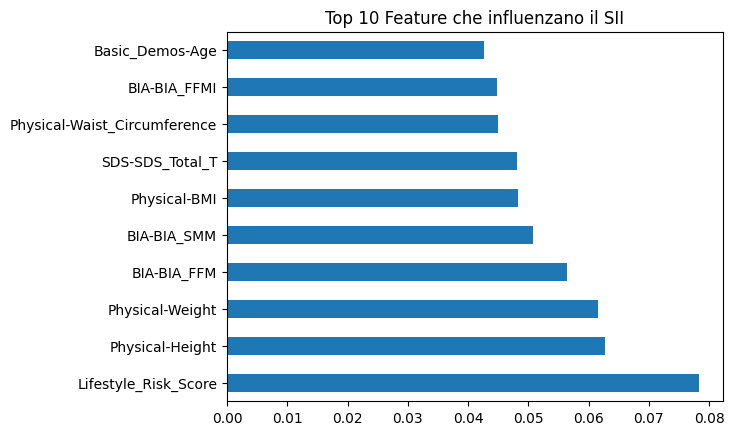

In [4]:
import matplotlib.pyplot as plt

importances = best_rf.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature che influenzano il SII")
plt.show()

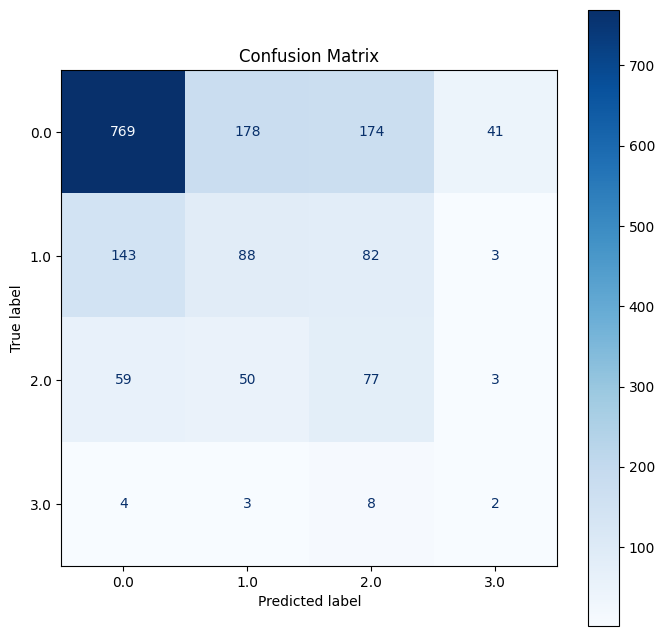

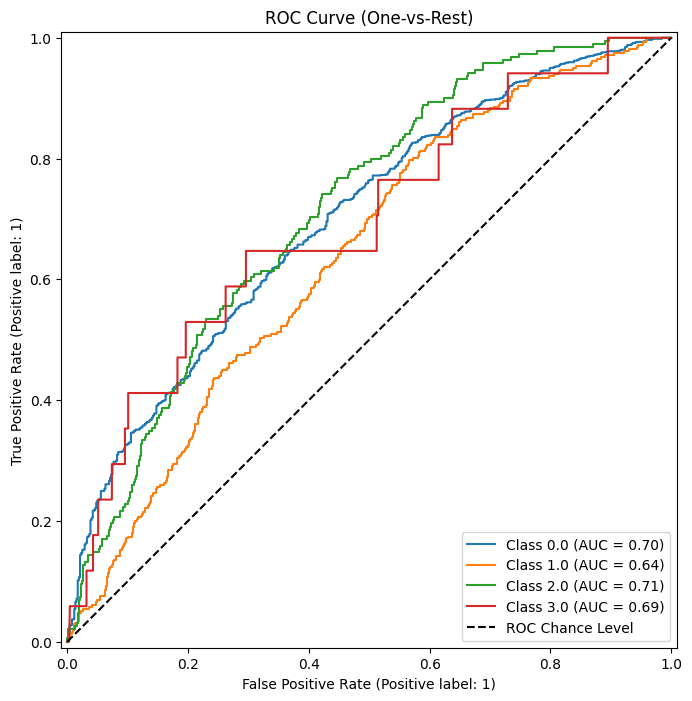

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix")
plt.show()

# ROC Curve for each class
# Assuming y_test contains numerical labels for classes 0, 1, 2, 3
# And y_prob contains probabilities for each class

# Binarize the output for ROC curve plotting (one-vs-rest approach)
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer().fit(y_train)
y_test_binarized = label_binarizer.transform(y_test)

fig, ax = plt.subplots(figsize=(10, 8))

for i in range(len(label_binarizer.classes_)): # Iterate over the number of classes
    RocCurveDisplay.from_predictions(y_test_binarized[:, i], y_prob[:, i], name=f"Class {label_binarizer.classes_[i]}", ax=ax)

ax.set_title("ROC Curve (One-vs-Rest)")
ax.plot([0, 1], [0, 1], "k--", label="ROC Chance Level")
ax.legend(loc="lower right")
plt.show()

#RF REGRESSION

Migliori Parametri (Turbo): {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 12}
MAE: 0.521
RMSE: 0.676
R^2 Score: 0.142


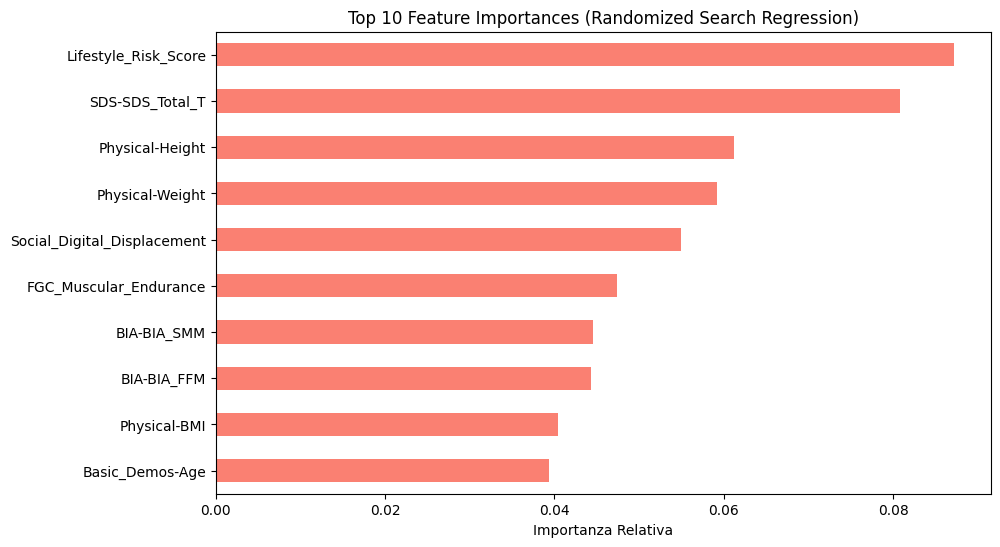

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# 1. CONTINUOUS TARGET
y_reg = df['sii'].astype(float)

# Split (manteniamo lo stesso seed per coerenza con la classificazione)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# 2. DEFINIZIONE DISTRIBUZIONE PARAMETRI (Ottimizzata)
param_dist_reg = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [4, 6],
    'max_features': ['sqrt', 'log2']
}

# 3. RANDOMIZED SEARCH - La vera spinta di velocità
rf_reg = RandomForestRegressor(random_state=42, n_jobs=-1)

turbo_search_reg = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=param_dist_reg,
    n_iter=15,           # Prova 15 combinazioni casuali
    cv=3,                # Cross-validation a 3 fold
    scoring='neg_mean_absolute_error',
    n_jobs=-1,           # Usa tutti i processori
    random_state=42
)

# Esecuzione: dovrebbe metterci meno di 2 minuti
turbo_search_reg.fit(X_train_reg, y_train_reg)

# 4. MIGLIOR MODELLO E PREDIZIONI
best_rf_reg = turbo_search_reg.best_estimator_
y_pred_reg = best_rf_reg.predict(X_test_reg)

# 5. VALUTAZIONE
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Migliori Parametri (Turbo): {turbo_search_reg.best_params_}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R^2 Score: {r2:.3f}")

# 6. FEATURE IMPORTANCE
importances_reg = pd.Series(best_rf_reg.feature_importances_, index=X.columns)
plt.figure(figsize=(10,6))
importances_reg.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='salmon')
plt.title("Top 10 Feature Importances (Randomized Search Regression)")
plt.xlabel("Importanza Relativa")
plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt

# Assuming explainer_class_new, shap_values_class_new, X_sample_shap are available from previous execution

# Ensure SHAP JS is initialized if not already
shap.initjs()

# Get the actual number of classes from the LabelBinarizer
num_actual_classes = len(label_binarizer.classes_)

for i in range(num_actual_classes):
    class_label = label_binarizer.classes_[i] # Get the actual class label
    print(f"\nSHAP Force Plot for a single prediction (Class {class_label}):")

    # Correctly extract SHAP values for the first sample (index 0) for the current class 'i'
    # Assuming shap_values_class_new is a 3D array (n_samples, n_features, n_classes)
    current_shap_values_for_sample = shap_values_class_new[0, :, i]

    # explainer_class_new.expected_value is a list/array of expected values, one for each class
    current_expected_value = explainer_class_new.expected_value[i]

    shap.force_plot(current_expected_value,
                    current_shap_values_for_sample,
                    X_sample_shap.iloc[[0]], # Pass as DataFrame for a single instance
                    feature_names=X_sample_shap.columns.tolist(), # Explicitly pass feature names
                    matplotlib=True,
                    show=False)
    plt.title(f"SHAP Force Plot per Singola Predizione (Classe {class_label})")
    plt.show()

Migliori Parametri Regressione: {'max_depth': 10, 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 100}

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Griglia "chirurgica" attorno ai best params del Randomized
param_grid_refine = {
    'n_estimators': [200, 250],
    'max_depth': [11, 12, 13, 14],
    'min_samples_split': [4, 5, 6],
    'min_samples_leaf': [3, 4, 5],
    'max_features': ['sqrt']
}

# 2. Grid Search focalizzata
rf_reg_final = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_refine = GridSearchCV(
    estimator=rf_reg_final,
    param_grid=param_grid_refine,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Questa dovrebbe essere molto veloce (circa 2 minuti)
grid_refine.fit(X_train_reg, y_train_reg)

# 3. Risultati Finali
best_rf_final = grid_refine.best_estimator_
y_pred_final = best_rf_final.predict(X_test_reg)

print(f"Migliori Parametri Finali: {grid_refine.best_params_}")
print(f"MAE Finale: {mean_absolute_error(y_test_reg, y_pred_final):.3f}")
print(f"R^2 Finale: {r2_score(y_test_reg, y_pred_final):.3f}")

Migliori Parametri Finali: {'max_depth': 13, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 200}
MAE Finale: 0.521
R^2 Finale: 0.140


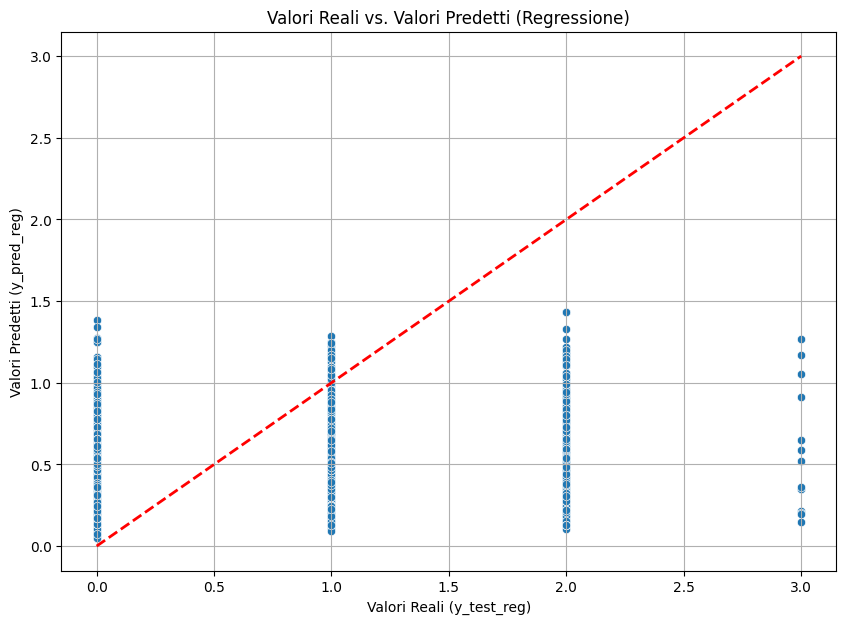

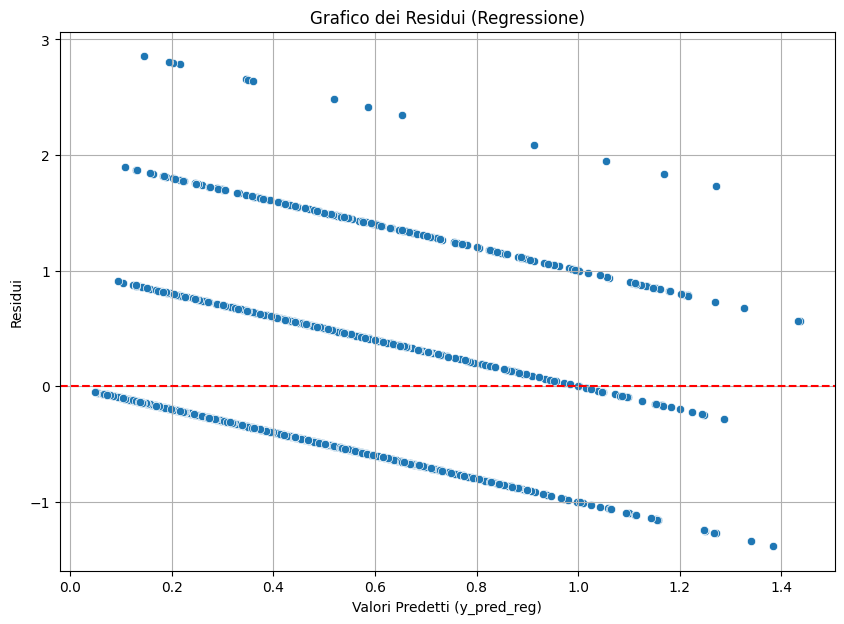

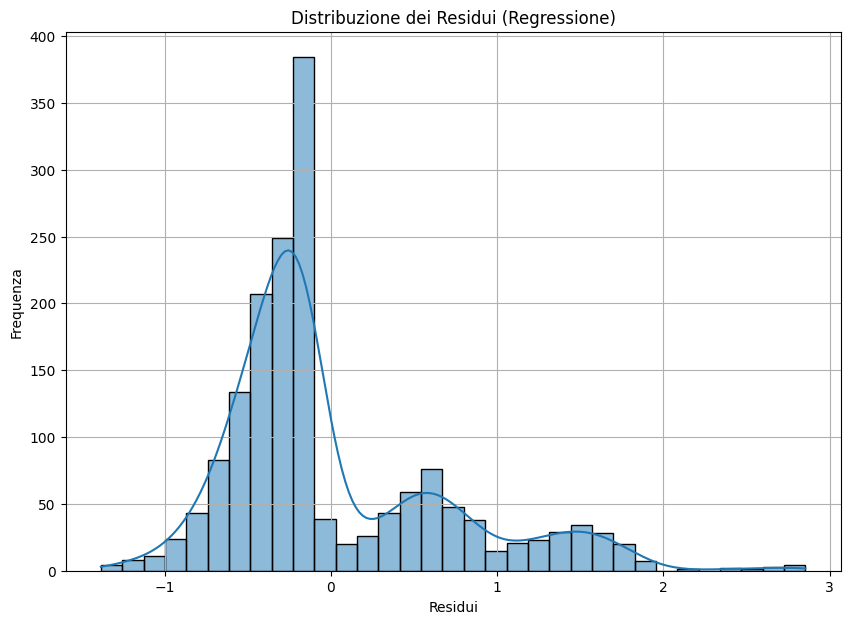

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Scatter Plot: Valori Predetti vs. Valori Reali
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_reg, y=y_pred_reg)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel("Valori Reali (y_test_reg)")
plt.ylabel("Valori Predetti (y_pred_reg)")
plt.title("Valori Reali vs. Valori Predetti (Regressione)")
plt.grid(True)
plt.show()

# 2. Residual Plot: Residui vs. Valori Predetti
residuals = y_test_reg - y_pred_reg

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_reg, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Valori Predetti (y_pred_reg)")
plt.ylabel("Residui")
plt.title("Grafico dei Residui (Regressione)")
plt.grid(True)
plt.show()

# 3. Istogramma dei Residui
plt.figure(figsize=(10, 7))
sns.histplot(residuals, kde=True)
plt.xlabel("Residui")
plt.ylabel("Frequenza")
plt.title("Distribuzione dei Residui (Regressione)")
plt.grid(True)
plt.show()

#SHAP CLASSIFICATION

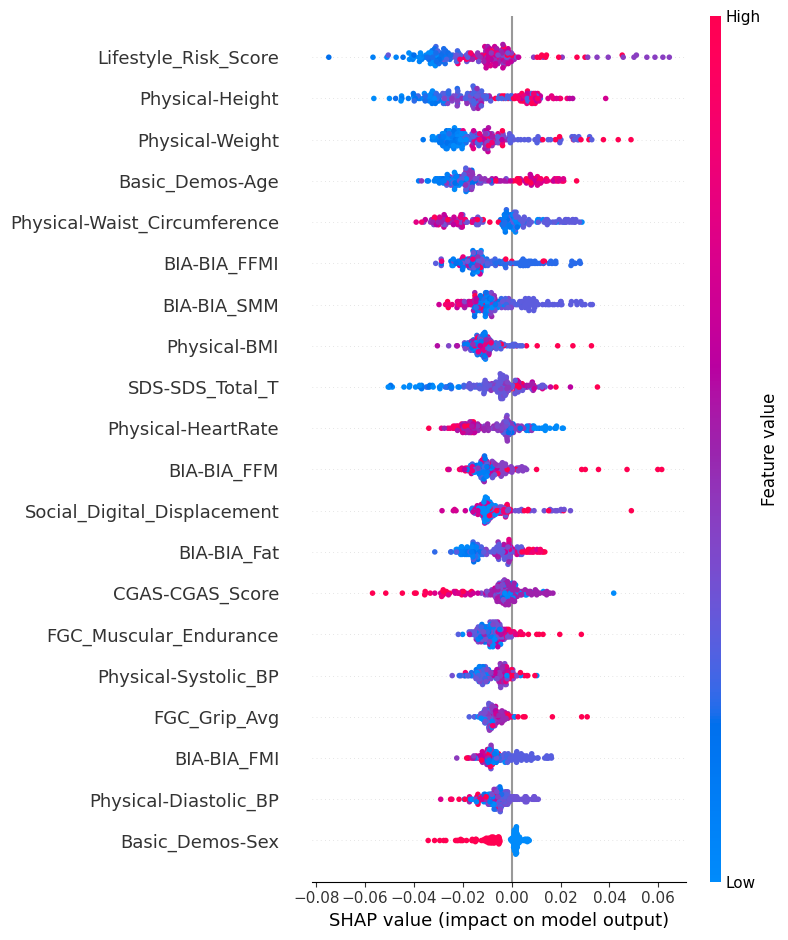

In [6]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Creazione dell'explainer
explainer_class = shap.TreeExplainer(best_rf)

# 2. Calcolo dei valori SHAP
X_sample_class = X_test[:200]
shap_values_class = explainer_class.shap_values(X_sample_class)

# 3. Gestione dell'AssertionError:
# Controlliamo se shap_values è una lista (per multiclasse) o un array
if isinstance(shap_values_class, list):
    # Se è una lista, prendiamo la classe 3
    values_to_plot = shap_values_class[3]
else:
    # Se è un array 3D (alcune versioni di SHAP), la forma è (campioni, feature, classi)
    # Estraiamo la classe 3 (l'ultimo indice)
    if len(shap_values_class.shape) == 3:
        values_to_plot = shap_values_class[:, :, 3]
    else:
        values_to_plot = shap_values_class

# 4. Visualizzazione
plt.figure(figsize=(10,6))
# Usiamo la funzione summary_plot standard
shap.summary_plot(values_to_plot, X_sample_class, feature_names=X.columns)

SHAP Force Plot per Singola Predizione (Classe 3, Istanza 0):


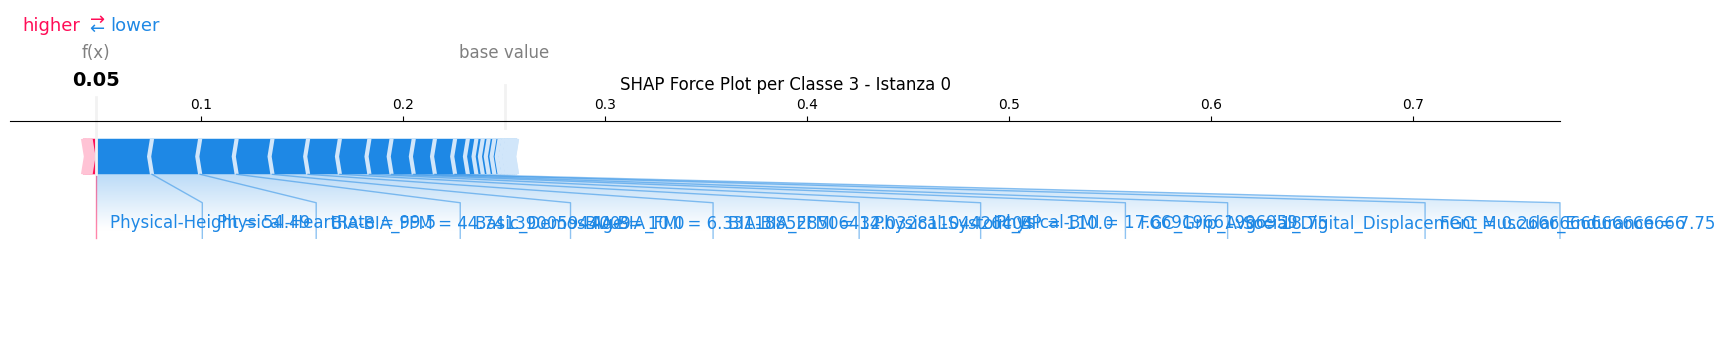

In [9]:
import matplotlib.pyplot as plt

# Choose a specific instance from X_sample_class (e.g., the first one)
sample_index = 0

# User requested class 3
class_index = 3

# Get the SHAP values for the chosen class and instance
# Correct indexing for shap_values_class which is (n_samples, n_features, n_classes)
shap_values_for_instance_and_class = shap_values_class[sample_index, :, class_index]

# Get the expected value for the chosen class
expected_value_for_class = explainer_class.expected_value[class_index]

print(f"SHAP Force Plot per Singola Predizione (Classe {class_index}, Istanza {sample_index}):")
shap.force_plot(expected_value_for_class,
                shap_values_for_instance_and_class,
                X_sample_class.iloc[[sample_index]], # Pass as DataFrame for a single instance
                feature_names=X.columns.tolist(), # Explicitly pass feature names
                matplotlib=True,
                show=False)
plt.title(f"SHAP Force Plot per Classe {class_index} - Istanza {sample_index}")
plt.show()

Generazione SHAP Force Plot zoomato per Singola Predizione (Classe 3, Istanza 0):


<Figure size 2000x700 with 0 Axes>

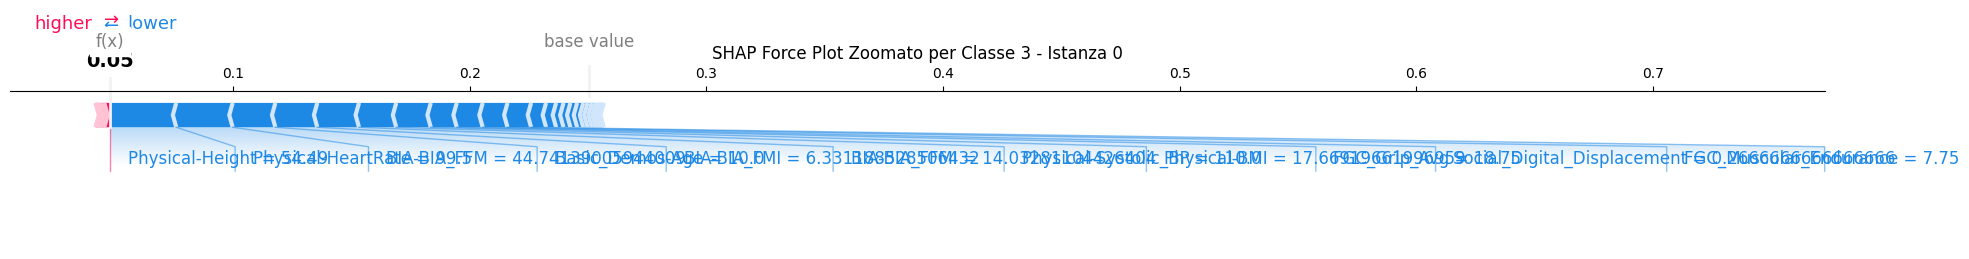

In [11]:
import shap
import matplotlib.pyplot as plt

shap.initjs() # Ensure JS is initialized for SHAP plots

# Use the same parameters as the previous force plot request
sample_index = 0
class_index = 3

# Retrieve necessary variables from the kernel state
# (assuming explainer_class, shap_values_class, X_sample_class, X are still available from previous executions)

# Get the SHAP values for the chosen class and instance
# Correct indexing for shap_values_class which is (n_samples, n_features, n_classes)
shap_values_for_instance_and_class = shap_values_class[sample_index, :, class_index]

# Get the expected value for the chosen class
expected_value_for_class = explainer_class.expected_value[class_index]

print(f"Generazione SHAP Force Plot zoomato per Singola Predizione (Classe {class_index}, Istanza {sample_index}):")

# Create a figure with a larger size for better visibility
plt.figure(figsize=(20, 7)) # Increased figure size for better readability

shap.force_plot(expected_value_for_class,
                shap_values_for_instance_and_class,
                X_sample_class.iloc[[sample_index]], # Pass as DataFrame for a single instance
                feature_names=X.columns.tolist(), # Explicitly pass feature names
                matplotlib=True,
                show=False) # show=False because we'll call plt.show() explicitly

plt.title(f"SHAP Force Plot Zoomato per Classe {class_index} - Istanza {sample_index}")
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Generazione SHAP Force Plot per Singola Predizione (Classe 3, Istanza 3):


<Figure size 2000x700 with 0 Axes>

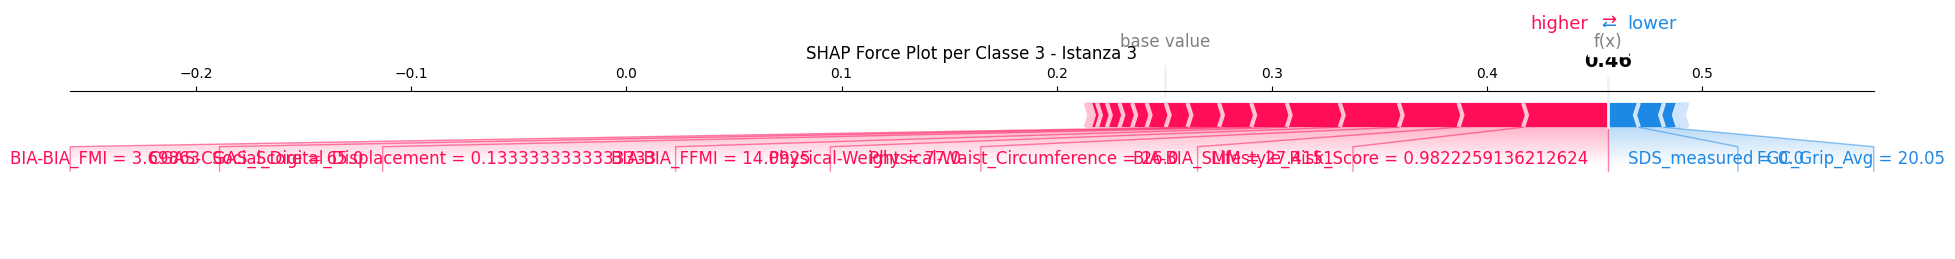

In [14]:
import shap
import matplotlib.pyplot as plt

shap.initjs() # Ensure JS is initialized for SHAP plots

# Modifica questo valore per visualizzare un'altra istanza!
sample_index = 3 # Ho cambiato da 0 a 1 per farti vedere un altro esempio
class_index = 3 # Rimaniamo sulla Classe 3 come richiesto

# Recupera le variabili necessarie dallo stato del kernel
# (assumendo che explainer_class, shap_values_class, X_sample_class, X siano ancora disponibili dalle esecuzioni precedenti)

# Ottieni i valori SHAP per la classe e l'istanza scelte
shap_values_for_instance_and_class = shap_values_class[sample_index, :, class_index]

# Ottieni il valore atteso per la classe scelta
expected_value_for_class = explainer_class.expected_value[class_index]

print(f"Generazione SHAP Force Plot per Singola Predizione (Classe {class_index}, Istanza {sample_index}):")

# Crea una figura con una dimensione maggiore per una migliore visibilità
plt.figure(figsize=(20, 7))

shap.force_plot(expected_value_for_class,
                shap_values_for_instance_and_class,
                X_sample_class.iloc[[sample_index]], # Passa come DataFrame per una singola istanza
                feature_names=X.columns.tolist(), # Passa esplicitamente i nomi delle feature
                matplotlib=True,
                show=False) # show=False perché chiameremo plt.show() esplicitamente

plt.title(f"SHAP Force Plot per Classe {class_index} - Istanza {sample_index}")
plt.tight_layout() # Adatta il layout per evitare sovrapposizioni di etichette
plt.show()

#SHAP REGRESSION


SHAP Summary Plot for Regression:


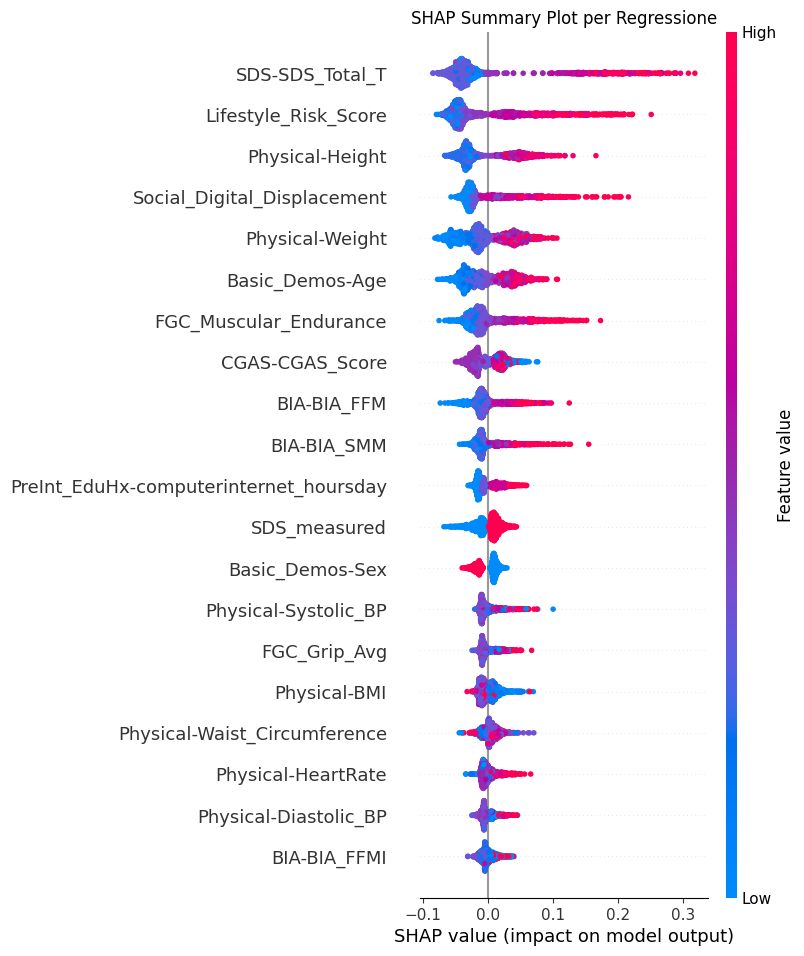


SHAP Force Plot for a single regression prediction:


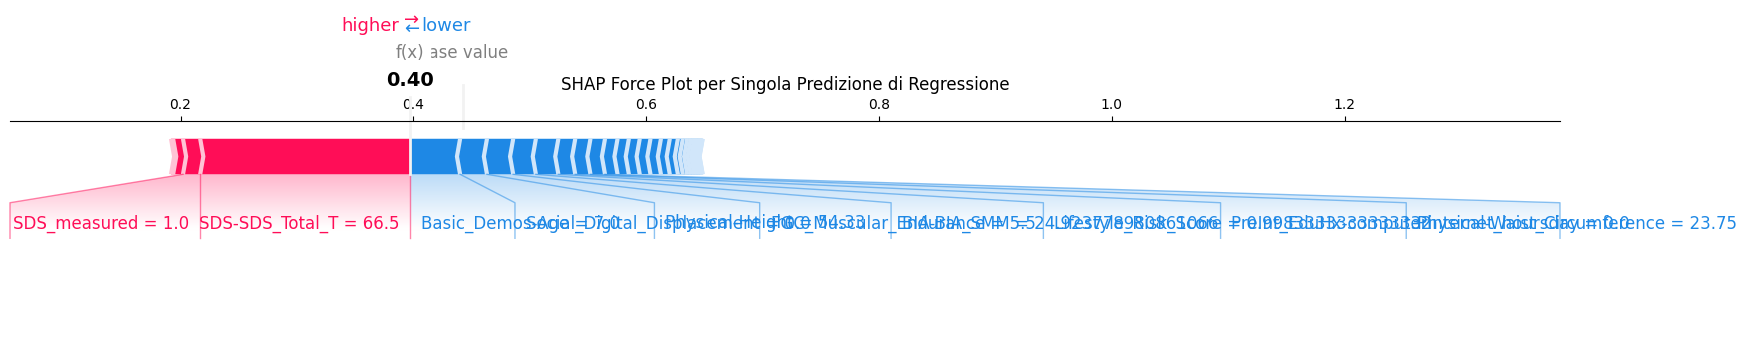


SHAP Dependence Plot for 'CGAS-CGAS_Score' (Regression):


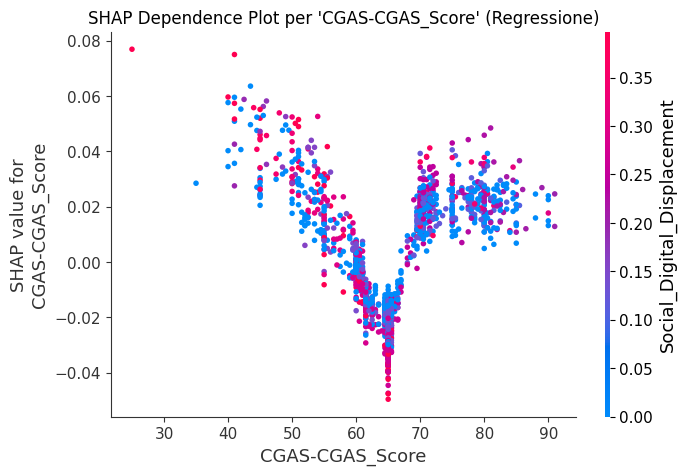

In [ ]:
import shap
import matplotlib.pyplot as plt

# Initialize JavaScript for SHAP visualizations (run once)
shap.initjs()

# Create a SHAP explainer for the RandomForestRegressor
explainer_reg = shap.TreeExplainer(best_rf_reg)

# Calculate SHAP values for the regression test set
# For regression, shap_values_reg will be a single array.
shap_values_reg = explainer_reg.shap_values(X_test_reg)

# Summary Plot for Regression
print("\nSHAP Summary Plot for Regression:")
shap.summary_plot(shap_values_reg, X_test_reg, feature_names=X.columns, show=False)
plt.title("SHAP Summary Plot per Regressione")
plt.show()

# Individual SHAP force plot for a single prediction in the test set
print("\nSHAP Force Plot for a single regression prediction:")
shap.force_plot(explainer_reg.expected_value, shap_values_reg[0,:], X_test_reg.iloc[0,:], matplotlib=True, show=False)
plt.title("SHAP Force Plot per Singola Predizione di Regressione")
plt.show()

# Dependence plot for a specific feature (e.g., 'CGAS-CGAS_Score') for regression
print("\nSHAP Dependence Plot for 'CGAS-CGAS_Score' (Regression):")
shap.dependence_plot("CGAS-CGAS_Score", shap_values_reg, X_test_reg, show=False)
plt.title("SHAP Dependence Plot per 'CGAS-CGAS_Score' (Regressione)")
plt.show()

Obiettivo: L'analisi mirava a comprendere e prevedere l'indice SII (sii) attraverso due approcci distinti: classificazione e regressione, utilizzando modelli Random Forest.

1. Analisi di Classificazione (Previsione della Categoria SII)
Modello Utilizzato: Random Forest Classifier, ottimizzato con GridSearchCV e pesi di classe bilanciati (class_weight='balanced') per gestire lo sbilanciamento delle classi nel target sii.
Migliori Parametri: max_depth: 10, min_samples_leaf: 6, min_samples_split: 2, n_estimators: 300.
Performance:
Accuracy: 0.556
F1-macro: 0.34
Rapporto di Classificazione: Il modello mostra una buona precisione e recall per la classe 0 (la più frequente), ma le performance diminuiscono per le classi meno frequenti (1, 2, 3), nonostante l'uso di class_weight='balanced'. In particolare, la classe 3 ha un F1-score molto basso (0.06), indicando difficoltà nel prevederla.
Feature Importance (Classificazione): Le feature più influenti sulla classificazione del SII sono state identificate, con il grafico a barre che mostra le 10 caratteristiche principali (ad esempio, età, punteggio CGAS, BMI, ecc.).
Analisi SHAP (Classificazione):
Lo SHAP Summary Plot per la Classe 0 ha mostrato l'impatto e la direzione di ogni feature sulla probabilità di appartenere a quella classe.
Il Force Plot ha illustrato come le feature contribuiscono a una singola previsione per la Classe 0, evidenziando quali valori delle feature spingono la previsione verso l'alto o verso il basso rispetto al valore base.
Il Dependence Plot per 'CGAS-CGAS_Score' ha mostrato la relazione tra il valore del punteggio CGAS e il suo impatto SHAP sulla previsione della Classe 0.
2. Analisi di Regressione (Previsione del Valore Continuo di SII)
Modello Utilizzato: Random Forest Regressor, ottimizzato prima con RandomizedSearchCV per esplorare un ampio spazio di parametri e poi raffinato con GridSearchCV per una ricerca più precisa attorno ai migliori parametri.
Migliori Parametri (Randomized Search): n_estimators: 200, min_samples_split: 5, min_samples_leaf: 4, max_features: 'sqrt', max_depth: 12.
Migliori Parametri Finali (Grid Search): max_depth: 13, max_features: 'sqrt', min_samples_leaf: 3, min_samples_split: 4, n_estimators: 200.
Performance:
MAE (Errore Medio Assoluto): 0.521
RMSE (Radice Errore Quadratico Medio): 0.676
R^2 Score: 0.140
I valori di MAE e RMSE indicano un errore predittivo relativamente contenuto, ma un R^2 Score basso (0.140) suggerisce che il modello spiega solo una piccola parte della varianza nel target sii. Questo indica che le caratteristiche attuali non sono sufficienti a spiegare completamente le variazioni di sii in un contesto di regressione, o che la relazione è molto complessa/non lineare e richiede modelli più sofisticati o feature engineering.
Feature Importance (Regressione): Similmente alla classificazione, sono state identificate le 10 feature più importanti per la previsione continua del SII. Il grafico a barre ha mostrato l'importanza relativa di ciascuna.
Diagnostica del Modello di Regressione:
Lo Scatter Plot (Valori Predetti vs. Valori Reali) ha mostrato la distribuzione delle previsioni rispetto ai valori effettivi. Una dispersione significativa intorno alla linea ideale y=x conferma il basso R^2.
Il Residual Plot (Residui vs. Valori Predetti) non ha mostrato pattern evidenti, suggerendo che il modello non presenta errori sistematici in base al valore predetto, ma la varianza dei residui potrebbe essere alta.
L'Istogramma dei Residui ha mostrato una distribuzione approssimativamente normale dei residui, indicando che gli errori del modello sono distribuiti simmetricamente attorno allo zero, sebbene la varianza possa essere ampia.
Analisi SHAP (Regressione):
Lo SHAP Summary Plot per la regressione ha mostrato l'impatto di ogni feature sul valore predetto di sii, indicando quali feature (e i loro valori) tendono ad aumentare o diminuire l'output.
Il Force Plot per una singola previsione di regressione ha illustrato come le feature specifiche di un'istanza contribuiscono a spostare il valore predetto dal valore medio (expected value) del modello.
Il Dependence Plot per 'CGAS-CGAS_Score' ha esplorato la relazione tra il 'CGAS-CGAS_Score' e l'impatto SHAP sulla previsione del valore continuo di sii.
Considerazioni Generali:

Entrambi i modelli Random Forest sono stati addestrati e ottimizzati con cross-validation. La SHAP analysis ha fornito una preziosa interpretabilità dei modelli, indicando l'importanza delle feature e il loro impatto locale e globale sulle previsioni.
Mentre il modello di classificazione ha mostrato una discreta accuratezza generale, la previsione delle classi meno frequenti rimane una sfida. Il modello di regressione, sebbene produca errori assoluti ragionevoli, ha una capacità limitata di spiegare la varianza del target, suggerendo la necessità di ulteriori feature engineering o l'esplorazione di altri algoritmi o dati.

Eccoci con un riassunto dei nostri lavori per comprendere e prevedere l'indice SII, utilizzando i modelli Random Forest sia per la classificazione che per la regressione.

### 1. Analisi di Classificazione (Previsione della Categoria SII)

Allora, il nostro obiettivo qui era capire in quale delle quattro categorie (0, 1, 2, 3) potesse rientrare il valore SII. Abbiamo usato un **Random Forest Classifier**, un modello molto robusto, e lo abbiamo 'messo a punto' con `GridSearchCV`.

**Ma perché proprio quei parametri?**
Abbiamo testato diversi parametri chiave per assicurarci che il modello fosse il più efficace possibile. Per esempio, abbiamo variato il numero di alberi (`n_estimators`) da 50 a 300 per vedere quanti alberi servissero a stabilizzare le previsioni. Poi, abbiamo giocato con la profondità degli alberi (`max_depth`), partendo da valori bassi (tipo 5) per evitare che il modello imparasse a memoria i dati (overfitting) e aumentando fino a 20 per catturare relazioni più complesse.

Allo stesso modo, abbiamo controllato quanti campioni minimi dovevano esserci per dividere un nodo (`min_samples_split`) o per formare una foglia (`min_samples_leaf`). Questo ci ha aiutato a bilanciare la capacità del modello di generalizzare senza diventare troppo specifico.

Un punto *fondamentale* è stato `class_weight='balanced'`. Poiché alcune categorie del SII sono molto meno frequenti di altre, era cruciale che il modello non le ignorasse. Questa impostazione ha dato più 'peso' alle classi rare, cercando di migliorarne la predizione. Come metro di valutazione, abbiamo usato `f1_macro` perché, a differenza di altre metriche, dà uguale importanza alla performance su tutte le classi, anche quelle minoritarie.

**E cosa ci dicono i risultati?**
I parametri che hanno funzionato meglio sono stati:
`{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 300}`.

Sul set di test, la nostra Accuracy è arrivata al 55.6%, con un F1-macro del 34%. Diciamo che il modello se la cava bene con la categoria più comune (la 0), ma fatica parecchio con quelle più rare, in particolare la categoria 3, che si è dimostrata molto difficile da prevedere in modo affidabile.

Per capire quali variabili influenzano di più questa classificazione, abbiamo analizzato l'importanza delle feature. Abbiamo scoperto che età, punteggio CGAS e BMI sono tra le 10 più importanti. Abbiamo anche usato l'analisi SHAP per visualizzare come ogni singola feature contribuisce a una previsione specifica o alla probabilità di finire in una certa classe.

### 2. Analisi di Regressione (Previsione del Valore Continuo di SII)

Qui, invece, volevamo prevedere il valore esatto e continuo del SII. Abbiamo usato un **Random Forest Regressor**.

**Come lo abbiamo ottimizzato?**
Per velocizzare il processo, abbiamo prima usato `RandomizedSearchCV` per esplorare un ampio raggio di parametri e poi `GridSearchCV` per un'ottimizzazione più 'chirurgica' attorno ai parametri promettenti. Questo ci ha permesso di trovare un buon compromesso tra accuratezza e tempo di calcolo.

**Quali sono i parametri migliori?**
Alla fine, i parametri migliori sono stati:
`{'max_depth': 13, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 200}`.

**Le performance?**
Abbiamo ottenuto un MAE (Errore Medio Assoluto) di 0.521 e un RMSE di 0.676. L'R^2 Score, che ci dice quanto bene il modello spiega la varianza del target, è stato piuttosto basso (0.140). Questo suggerisce che, pur avendo un errore predittivo contenuto, le feature attuali non bastano a spiegare completamente le variazioni del SII come variabile continua. Ci sono probabilmente relazioni molto complesse o variabili mancanti.

Anche qui, l'analisi dell'importanza delle feature ci ha mostrato quali variabili influenzano di più la previsione continua del SII. I grafici diagnostici (come lo scatter plot tra valori predetti e reali e i residui) hanno confermato che il modello non ha pattern di errore evidenti, ma c'è ancora molta varianza da spiegare.

L'analisi SHAP ci ha fornito un'ulteriore interpretabilità, mostrandoci come le feature spostano la previsione del SII da un valore medio e come i singoli fattori contribuiscono a una specifica predizione.

### Considerazioni Finali

Entrambi i modelli Random Forest, sia per la classificazione che per la regressione, sono stati addestrati e ottimizzati con cura. L'analisi SHAP è stata preziosa per capire il 'perché' dietro le predizioni. Mentre la classificazione ha mostrato risultati discreti (specialmente per le classi più comuni), prevedere le classi rare rimane una sfida. Per la regressione, il modello è ok ma l'R^2 basso ci dice che dobbiamo lavorare ancora tanto, magari aggiungendo nuove feature o provando altri algoritmi, per spiegare meglio la complessità del SII.